# Day-Ahead Power Positioning — Research Evaluation

A retrospective research experiment with development-only model and signal selection. The historically inspected 2018 evaluation tail is excluded from the current selection procedure; it is not a new untouched sample. Position quantities use a fixed £50/MWh pre-auction sizing reference and dated settlement equity. Costs and fills remain stylised.


In [1]:
%matplotlib inline

import json
import shutil
import subprocess
import sys
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

PYTHON = sys.executable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.utils.provenance import fingerprint, cache_matches, write_manifest
from src.utils.config import RAW_DATA_DIR


No event loop hook running.


In [2]:
ANALYSIS_START = "2018-01-01"
ANALYSIS_END = "2019-01-01"  # exclusive London market-date boundary


---
## Section 1 — The Seasonally-Aware Baseline

Before deploying machine learning to proxy system imbalance, we must establish what a naive seasonal rule can achieve. The **7-Day Naive Baseline** assumes the forward price deviation in the current half-hour mirrors the exact same half-hour one week prior.

This accounts for the strong intra-day and day-of-week seasonality in GB power markets. An ML model that cannot outperform this 7-day floor is not earning its complexity and cannot be trusted to model residual load dynamics.

In [3]:
# The baseline is computed immediately after the verified feature build below.


---
## Section 2 — Model comparison

All candidates use 200 training days, 30-day development folds and a reserved 60-market-day evaluation tail. The 14 inputs are auction-vintage wind and demand, demand minus wind, pre-auction wind drift, 48/72-hour lagged DA and cash-out prices and their gap, plus cyclical London hour and weekday. Realised generation, forecast errors and current prices are not model inputs.

Linear regression, random forest and XGBoost baselines compete with the tuned XGBoost grid on development MAE; the best candidate advances to signal selection.


In [4]:
# Every sweep config carries the same holdout. The last 60 market days are cut
# off before any folding and are never scored during selection, so the tournament
# below runs entirely on the development period and the winner is scored on the
# holdout exactly once, at the end.
HOLDOUT_DAYS = 60


def write_config(run_name, model_type, model_params=None, train_days=200,
                 threshold=5.0, top_n=5, transaction_cost=0.0,
                 vol_multiplier=0.0, evaluate_holdout=False):
    cfg = {
        "strategy": "da_positioning",
        "strategy_type": "virtual",
        "run_name": run_name,
        "training_cache_dir": "artifacts/da_positioning/_training_cache",
        "data": {
            "periods": [
                {"start": "2018-01-01", "end": "2019-01-01", "demand_source": "NESO_API"}
            ],
            "wind_source":            "ELEXON",
            "generation_source":      "ELEXON",
            "day_ahead_price_source": "ENTSOE",
            "market_index_source":    "ELEXON",
            "demand_actual_source":   "ELEXON",
            "imbalance_source":       "ELEXON",
        },
        "model": {"type": model_type, "hyperparameters": model_params or {}},
        "validation": {"type": "walk_forward", "train_days": train_days,
                       "test_days": 30, "step_days": 30,
                       "holdout_days": HOLDOUT_DAYS, "evaluate_holdout": evaluate_holdout},
        # vol_multiplier is swept rather than left at its old default of 1.0.
        # That default was calibrated against a volatility series that was
        # identically zero (SBP - SSP under single cash-out pricing), so it had
        # never actually been tested; against the real cash-out-to-auction gap a
        # multiplier of 1.0 fires 26 times in the whole year.
        "signal": {"threshold": threshold, "top_n": top_n,
                   "transaction_cost": transaction_cost,
                   "vol_multiplier": vol_multiplier, "vol_window": 336},
        "execution": {
            "baseline_hedge_ratio":  0.0,
            "take_profit_pct":       999.0,
            "stop_loss_price_delta": 999.0,
            "slippage":              2.00,
        }
    }
    path = REPO_ROOT / (f"artifacts/sweeps/{run_name}.yaml")
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False)
    return str(path)


# The tournament varies only signal and execution parameters, so every run in it
# shares one feature set. Building it once and copying it in is not just faster
# (108 rebuilds of the same parquet is about four hours of re-reading the same
# cached JSON) — it also guarantees the runs are comparable, because a rebuild
# per run is a chance for them to diverge.
# setup_experiment_paths lays a run out as <run_name>/features/features.parquet,
# so the shared build lands one directory deeper than the run name.
SHARED_FEATURES = (
    REPO_ROOT / "artifacts" / "da_positioning" / "_shared" / "features" / "features.parquet"
)


def build_shared_features(reference_run="_shared"):
    """Build the feature set the whole tournament runs on, once."""
    path = write_config(reference_run, "xgboost")
    data_config = yaml.safe_load(Path(path).read_text())["data"]
    expected = fingerprint(REPO_ROOT, data_config, raw_dir=Path(RAW_DATA_DIR))
    manifest = SHARED_FEATURES.with_suffix(".manifest.json")
    if SHARED_FEATURES.exists() and cache_matches(manifest, expected):
        print(f"  reusing verified {SHARED_FEATURES.relative_to(REPO_ROOT)}")
        return
    result = subprocess.run(
        [PYTHON, str(REPO_ROOT / "main.py"), "--config", path, "--mode", "features"],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError("Feature build failed")
    if not SHARED_FEATURES.exists():
        raise RuntimeError(
            f"Feature build reported success but {SHARED_FEATURES} is absent — "
            "check where setup_experiment_paths put it."
        )
    write_manifest(manifest, fingerprint(REPO_ROOT, data_config, raw_dir=Path(RAW_DATA_DIR)))
    print(f"  built {SHARED_FEATURES.relative_to(REPO_ROOT)}")


def run_experiment(config_path, run_name=None):
    # Idempotent: the tournament is deterministic, so a run whose metrics
    # already exist is served from its artifact. Delete the run's folder under
    # artifacts/da_positioning/ to force a re-run.
    cfg = yaml.safe_load(Path(config_path).read_text())
    expected = fingerprint(REPO_ROOT, cfg, features=SHARED_FEATURES)
    if run_name is not None:
        _m = REPO_ROOT / (f"artifacts/da_positioning/{run_name}/virtual/trading/metrics.json")
        manifest = _m.with_suffix(".manifest.json")
        if _m.exists() and cache_matches(manifest, expected):
            print("  cached — skipping")
            return
        dest = REPO_ROOT / f"artifacts/da_positioning/{run_name}/features/features.parquet"
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(SHARED_FEATURES, dest)

    from src.pipeline import run_full_pipeline
    from contextlib import chdir
    with chdir(REPO_ROOT):
        run_full_pipeline(mode="model", config=cfg, skip_features=True)
    if run_name is not None:
        write_manifest(manifest, expected)


def load_metrics(run_name):
    path = REPO_ROOT / (f"artifacts/da_positioning/{run_name}/virtual/trading/metrics.json")
    with open(path) as f:
        return json.load(f)


def development_metrics(run_name):
    """Trading metrics for the development period only.

    The tournament must never rank on anything that has seen the holdout, and the
    top-level `trading_performance` block covers the whole series — development
    and holdout together. Selecting on that would spend the holdout on the very
    search it exists to be independent of.
    """
    m = load_metrics(run_name)
    by_split = m.get("trading_performance_by_split", {})
    if "development" not in by_split:
        raise KeyError(
            f"{run_name} has no development split — re-run it with "
            "validation.holdout_days set, or its result cannot be used for selection."
        )
    return by_split["development"]


S2_CONFIGS = [
    ("s2_lr",  "linear_regression", {}),
    ("s2_rf",  "random_forest",     {}),
    ("s2_xgb", "xgboost",           {"n_estimators": 400, "max_depth": 4,
                                      "learning_rate": 0.03, "subsample": 0.8,
                                      "colsample_bytree": 0.7}),
]

print("Building the shared feature set for the tournament...")
build_shared_features()

proc = pd.read_parquet(SHARED_FEATURES)
proc["time"] = pd.to_datetime(proc["time"], utc=True)
proc = proc.sort_values("time").reset_index(drop=True)

# Spread = imbalance settlement (SSP) minus the day-ahead auction price
proc["actual_spread"] = proc["system_sell_price"] - proc["day_ahead_price"]

# 7-day naive seasonal lag: 7 days x 48 half-hours = 336 periods
proc["naive_baseline"] = proc["actual_spread"].shift(336)

proc = proc[(proc.time >= pd.Timestamp(ANALYSIS_START, tz="Europe/London")) &
            (proc.time < pd.Timestamp(ANALYSIS_END, tz="Europe/London"))].copy()
valid = proc.dropna(subset=["actual_spread", "naive_baseline"])
baseline_mae = mean_absolute_error(valid["actual_spread"], valid["naive_baseline"])

print(f"Dataset:                   {proc['time'].min().date()} to {proc['time'].max().date()}")
print(f"Total half-hour periods:   {len(proc):,}")
print(f"Spread std:                {valid['actual_spread'].std():.2f} GBP/MWh")
print()
print(f"7-Day Naive Baseline MAE:  {baseline_mae:.2f} GBP/MWh")
print(f"Any model must beat {baseline_mae:.2f} GBP/MWh to justify its complexity.")

for run_name, model_type, params in S2_CONFIGS:
    path = write_config(run_name, model_type, model_params=params)
    print(f"Running {run_name} ({model_type})...")
    run_experiment(path, run_name)
    print(f"  done")

Building the shared feature set for the tournament...
  reusing verified artifacts/da_positioning/_shared/features/features.parquet
Dataset:                   2018-01-01 to 2018-12-31
Total half-hour periods:   17,520
Spread std:                27.90 GBP/MWh

7-Day Naive Baseline MAE:  23.73 GBP/MWh
Any model must beat 23.73 GBP/MWh to justify its complexity.
Running s2_lr (linear_regression)...
  cached — skipping
  done
Running s2_rf (random_forest)...
  cached — skipping
  done
Running s2_xgb (xgboost)...
  cached — skipping
  done


In [5]:
s2_rows = []
for run_name, model_type, _ in S2_CONFIGS:
    m = load_metrics(run_name)
    mp = m["model_performance"]["by_split"]["development"]
    tp = development_metrics(run_name)
    s2_rows.append({
        "Model":           model_type.replace("_", " ").title(),
        "MAE (GBP/MWh)":  round(mp["mae"], 3),
        "RMSE (GBP/MWh)": round(mp["rmse"], 3),
        "Dir. Accuracy":   f"{mp['directional_accuracy']:.1%}",
        "Sharpe":          round(tp["sharpe_ratio"], 3),
        "Total Return":    f"{tp['total_return_pct']:+.1%}",
    })

s2_df = pd.DataFrame(s2_rows)
print(f"Baseline MAE to beat: {baseline_mae:.2f} GBP/MWh\n")
s2_df

Baseline MAE to beat: 23.73 GBP/MWh

Out[5]: 
               Model  MAE (GBP/MWh)  ...  Sharpe Total Return
0  Linear Regression         17.406  ...   4.196       +72.4%
1      Random Forest         17.693  ...   1.944       +22.6%
2            Xgboost         17.744  ...   4.388       +91.3%

[3 rows x 6 columns]


,Model,MAE (GBP/MWh),RMSE (GBP/MWh),Dir. Accuracy,Sharpe,Total Return
0,Linear Regression,17.406,22.658,56.5%,4.196,+72.4%
1,Random Forest,17.693,22.753,53.4%,1.944,+22.6%
2,Xgboost,17.744,22.914,54.3%,4.388,+91.3%


---
## Section 3 — Development walk-forward calibration

Fit the XGBoost depth/rate grid, then rank it together with all three family baselines on development MAE. Trading metrics are descriptive at this stage. Label availability uses settlement-period end plus a one-hour publication assumption before the D−1 10:30 London decision. Revised historical data are not a point-in-time publication archive.


In [6]:
s3_results = []

for depth, lr in product([3, 4, 5], [0.01, 0.05, 0.1]):
    lr_tag = str(lr).replace(".", "")
    run_name = f"s3_d{depth}_lr{lr_tag}"
    params = {
        "n_estimators":    400,
        "max_depth":       depth,
        "learning_rate":   lr,
        "subsample":       0.8,
        "colsample_bytree": 0.7,
    }
    path = write_config(run_name, "xgboost", model_params=params)
    print(f"Running {run_name}  (max_depth={depth}, learning_rate={lr})...")
    run_experiment(path, run_name)

    m = load_metrics(run_name)
    mp = m["model_performance"]["by_split"]["development"]
    tp = development_metrics(run_name)
    s3_results.append({
        "run_name":       run_name,
        "max_depth":      depth,
        "learning_rate":  lr,
        "mae":            mp["mae"],
        "dir_accuracy":   mp["directional_accuracy"],
        "sharpe":         tp["sharpe_ratio"],
        "total_return":   tp["total_return_pct"],
    })
    print(f"  MAE={mp['mae']:.3f}  Dir.Acc={mp['directional_accuracy']:.1%}  Sharpe={tp['sharpe_ratio']:.2f}")
for run_name, model_type, params in S2_CONFIGS:
    mp = load_metrics(run_name)["model_performance"]["by_split"]["development"]
    tp = development_metrics(run_name)
    s3_results.append(dict(run_name=run_name, max_depth=np.nan, learning_rate=np.nan,
                           mae=mp["mae"], dir_accuracy=mp["directional_accuracy"],
                           sharpe=tp["sharpe_ratio"], total_return=tp["total_return_pct"]))


Running s3_d3_lr001  (max_depth=3, learning_rate=0.01)...
  cached — skipping
  MAE=17.612  Dir.Acc=54.8%  Sharpe=5.83
Running s3_d3_lr005  (max_depth=3, learning_rate=0.05)...
  cached — skipping
  MAE=17.670  Dir.Acc=54.0%  Sharpe=5.46
Running s3_d3_lr01  (max_depth=3, learning_rate=0.1)...
  cached — skipping
  MAE=18.045  Dir.Acc=51.9%  Sharpe=3.13
Running s3_d4_lr001  (max_depth=4, learning_rate=0.01)...
  cached — skipping
  MAE=17.658  Dir.Acc=53.7%  Sharpe=5.64
Running s3_d4_lr005  (max_depth=4, learning_rate=0.05)...
  cached — skipping
  MAE=17.923  Dir.Acc=53.6%  Sharpe=2.83
Running s3_d4_lr01  (max_depth=4, learning_rate=0.1)...
  cached — skipping
  MAE=18.340  Dir.Acc=51.6%  Sharpe=3.69
Running s3_d5_lr001  (max_depth=5, learning_rate=0.01)...
  cached — skipping
  MAE=17.665  Dir.Acc=53.6%  Sharpe=4.21
Running s3_d5_lr005  (max_depth=5, learning_rate=0.05)...
  cached — skipping
  MAE=18.187  Dir.Acc=50.8%  Sharpe=1.69
Running s3_d5_lr01  (max_depth=5, learning_rate=0.1)

In [7]:
s3_df = pd.DataFrame(s3_results).sort_values("mae").reset_index(drop=True)

display_df = s3_df.copy()
display_df["MAE (GBP/MWh)"]  = display_df["mae"].map("{:.3f}".format)
display_df["Dir. Accuracy"]   = display_df["dir_accuracy"].map("{:.1%}".format)
display_df["Sharpe"]          = display_df["sharpe"].map("{:.2f}".format)
display_df["Total Return"]    = display_df["total_return"].map("{:+.1%}".format)

print("=== Section 3 Leaderboard — Ranked by Lowest MAE ===\n")
display(
    display_df[["run_name", "max_depth", "learning_rate",
                "MAE (GBP/MWh)", "Dir. Accuracy", "Sharpe", "Total Return"]]
)

best_row   = s3_df.iloc[0]
selected_model_cfg = yaml.safe_load((REPO_ROOT / f"artifacts/sweeps/{best_row['run_name']}.yaml").read_text())["model"]
selected_model_type = selected_model_cfg["type"]
best_params_s3 = selected_model_cfg["hyperparameters"]
print(f"Selected model: {selected_model_type}; parameters: {best_params_s3}")
print(f"Development MAE: {best_row['mae']:.3f} GBP/MWh")


=== Section 3 Leaderboard — Ranked by Lowest MAE ===

Selected model: linear_regression; parameters: {}
Development MAE: 17.406 GBP/MWh


,run_name,max_depth,learning_rate,MAE (GBP/MWh),Dir. Accuracy,Sharpe,Total Return
0,s2_lr,NaN,NaN,17.406,56.5%,4.20,+72.4%
1,s3_d3_lr001,3.000,0.010,17.612,54.8%,5.83,+117.1%
2,s3_d4_lr001,4.000,0.010,17.658,53.7%,5.64,+112.4%
3,s3_d5_lr001,5.000,0.010,17.665,53.6%,4.21,+74.6%
4,s3_d3_lr005,3.000,0.050,17.670,54.0%,5.46,+116.4%
5,s2_rf,NaN,NaN,17.693,53.4%,1.94,+22.6%
6,s2_xgb,NaN,NaN,17.744,54.3%,4.39,+91.3%
7,s3_d4_lr005,4.000,0.050,17.923,53.6%,2.83,+51.6%
8,s3_d3_lr01,3.000,0.100,18.045,51.9%,3.13,+56.6%
9,s3_d5_lr005,5.000,0.050,18.187,50.8%,1.69,+24.5%


### Candidate stability

The following dispersion is descriptive of the development search, not a confidence interval or an independent estimate of performance.


In [8]:
# Dispersion of trading outcomes across the hyperparameter grid.
_mae_range = s3_df["mae"].max() - s3_df["mae"].min()
print(f"MAE range across grid   : {_mae_range:.3f} GBP/MWh "
      f"({_mae_range / s3_df['mae'].min():.1%} of best)")
print(f"Sharpe across same grid : {s3_df['sharpe'].min():+.2f} to {s3_df['sharpe'].max():+.2f}")
print(f"Grid median Sharpe      : {s3_df['sharpe'].median():+.2f}   (central estimate)")
print(f"Profitable configs      : {(s3_df['total_return'] > 0).sum()}/{len(s3_df)}")
_sel_by_sharpe = s3_df.loc[s3_df["sharpe"].idxmax()]
print(f"Selection on Sharpe would pick {_sel_by_sharpe['run_name']} "
      f"(MAE {_sel_by_sharpe['mae']:.3f}, {(_sel_by_sharpe['mae']/s3_df['mae'].min()-1):+.1%} "
      f"vs best). Not used.")

MAE range across grid   : 1.182 GBP/MWh (6.8% of best)
Sharpe across same grid : +1.69 to +5.83
Grid median Sharpe      : +3.94   (central estimate)
Profitable configs      : 12/12
Selection on Sharpe would pick s3_d3_lr001 (MAE 17.612, +1.2% vs best). Not used.


---
## Section 4 — Execution Sweep: Liquidity & Risk Constraints

A predictive edge is irrelevant if it cannot survive market friction. We now stress-test the calibrated ML model against our two primary execution constraints:

| Parameter | Values tested | Market Reality |
|---|---|---|
| `signal.top_n` | 5, 10, 15 | Approximates liquidity and capital allocation limits. Concentrates risk in highest-confidence signals. |
| `signal.threshold` | 3.0, 5.0, 7.0 | Volatility gating. At TC = £1.00/MWh, a threshold < 2× TC produces indefensible net margin; 3.0 is the minimum defensible floor. |
| `transaction_cost` | £0.50, £1.00, £2.00/MWh | Execution friction swept across plausible fill-quality scenarios; £1.00/MWh is the target operating tier for live deployment. |

**Best-run selection — one rule, stated once and applied mechanically:**

> Within the TC = £1.00/MWh tier, keep configurations executing **at least 1.0 trade per market day** on the *development* period, then rank by **development Sharpe**, tie-breaking on return-to-drawdown.

Every grid endpoint is included. The floor is expressed per day rather than as an absolute count so it does not silently change meaning when the development window does: the previous prose said 500 trades while the code applied 1,000, and those two rules select different winners (top-5/£5 and top-10/£5 respectively).

Sharpe here is computed on **daily percentage returns**, because position size scales with equity. Calmar is reported but not used to select: annualising a 90-day return makes it unstable, and the figure this repo previously called "Calmar" was total-window return over drawdown-against-opening-capital, which is a different quantity from the conventional ratio. Both are now reported under their own names (`calmar_ratio`, `return_to_dd`).

**None of these numbers are the out-of-sample result.** Model, signal and execution parameters are all chosen by reading development folds, so the development curve is an artefact of that search. The reserved 60-day retrospective evaluation split at the end of the notebook is evaluated separately and was inspected in prior research.

The heatmap below visualises Sharpe across the parameter grid (exploration); the scatter plots trade count vs. Calmar (a descriptive metric).

All configurations in this sweep run with the execution layer disabled
(`baseline_hedge_ratio: 0.0`, TP/SL inactive); positions settle at imbalance. The sweep
therefore selects signal-layer parameters only. The execution layer is calibrated
separately in notebook 02 on the selected signals, keeping the two selection problems
independent.

In [9]:
# vol_multiplier joins the sweep. It used to sit at 1.0 as an untested default,
# because the series it scaled — the rolling std of (SBP - SSP) — is zero in
# every settlement period under GB single cash-out pricing. Rebuilt against the
# cash-out-to-auction gap it is a real quantity (median about GBP 21/MWh), which
# makes 1.0 an extremely wide gate rather than a neutral one.
s4_results = []
GRID = product([5, 10, 15], [3.0, 5.0, 7.0], [0.0, 0.25, 0.50, 1.0], [0.50, 1.00, 2.00])

for top_n, threshold, vm, tc in GRID:
    tc_tag = str(tc).replace(".", "")
    vm_tag = str(vm).replace(".", "")
    run_name = f"s4_n{top_n}_t{int(threshold * 10)}_vm{vm_tag}_tc{tc_tag}"
    path = write_config(
        run_name, selected_model_type,
        model_params=best_params_s3,
        threshold=threshold,
        top_n=top_n,
        transaction_cost=tc,
        vol_multiplier=vm,
    )
    print(f"Running {run_name}  (top_n={top_n}, thr={threshold}, vol_mult={vm}, tc={tc})...")
    run_experiment(path, run_name)

    # Development only. Ranking on the blended series would let the holdout into
    # the search it exists to be independent of.
    tp = development_metrics(run_name)
    days = tp.get("daily_summary", {}).get("total_days") or 1

    s4_results.append({
        "run_name":         run_name,
        "top_n":            top_n,
        "threshold":        threshold,
        "vol_multiplier":   vm,
        "transaction_cost": tc,
        "sharpe":           tp["sharpe_ratio"],
        "calmar":           tp.get("calmar_ratio"),
        "return_to_dd":     tp.get("return_to_dd"),
        "profit_factor":    tp["profit_factor"],
        "total_return":     tp["total_return_pct"],
        "win_rate":         tp["win_rate"],
        "n_trades":         tp["n_trades"],
        "development_days": days,
        "trades_per_day":   tp["n_trades"] / days,
        "total_position_mwh":      tp.get("total_position_mwh"),
        "total_transaction_costs": tp.get("total_transaction_costs"),
        "max_drawdown":     tp["max_drawdown"],
    })
    print(f"  Sharpe={tp['sharpe_ratio']:.2f}  Return={tp['total_return_pct']:+.1%}  "
          f"Trades={tp['n_trades']} ({tp['n_trades'] / days:.2f}/day)")


Running s4_n5_t30_vm00_tc05  (top_n=5, thr=3.0, vol_mult=0.0, tc=0.5)...
  cached — skipping
  Sharpe=4.21  Return=+85.5%  Trades=510 (5.67/day)
Running s4_n5_t30_vm00_tc10  (top_n=5, thr=3.0, vol_mult=0.0, tc=1.0)...
  cached — skipping
  Sharpe=3.82  Return=+72.1%  Trades=492 (5.47/day)
Running s4_n5_t30_vm00_tc20  (top_n=5, thr=3.0, vol_mult=0.0, tc=2.0)...
  cached — skipping
  Sharpe=1.78  Return=+23.2%  Trades=425 (4.72/day)
Running s4_n5_t30_vm025_tc05  (top_n=5, thr=3.0, vol_mult=0.25, tc=0.5)...
  cached — skipping
  Sharpe=3.20  Return=+47.0%  Trades=363 (4.03/day)
Running s4_n5_t30_vm025_tc10  (top_n=5, thr=3.0, vol_mult=0.25, tc=1.0)...
  cached — skipping
  Sharpe=2.63  Return=+34.3%  Trades=322 (3.58/day)
Running s4_n5_t30_vm025_tc20  (top_n=5, thr=3.0, vol_mult=0.25, tc=2.0)...
  cached — skipping
  Sharpe=0.71  Return=+5.5%  Trades=254 (2.82/day)
Running s4_n5_t30_vm05_tc05  (top_n=5, thr=3.0, vol_mult=0.5, tc=0.5)...
  cached — skipping
  Sharpe=-2.64  Return=-7.7%  Tr

2026-09-10 13:29:12,142 - src.pipeline - INFO - Starting pipeline in 'model' mode
2026-09-10 13:29:12,142 - src.pipeline - INFO - Skipping feature build, retraining on existing features
2026-09-10 13:29:12,142 - src.pipeline - INFO - Training model
2026-09-10 13:29:12,290 - src.pipeline - INFO - Generating trading signals
2026-09-10 13:29:12,291 - src.models.signal - INFO - Raw signals — LONG: 167 (4.6%)  SHORT: 1415 (39.0%)  NEUTRAL: 2045 (56.4%)
2026-09-10 13:29:12,295 - src.models.signal - INFO - Daily schedule (top-15 per direction): 1582 → 1130 active signals retained
2026-09-10 13:29:12,296 - src.pipeline - INFO - Running backtest
2026-09-10 13:29:12,311 - src.backtest.engine - INFO - Backtest complete (auction-book sizing)
2026-09-10 13:29:12,311 - src.backtest.engine - INFO -   Starting capital: £    50,000
2026-09-10 13:29:12,311 - src.backtest.engine - INFO -   Final capital:    £   163,700  (+227.4%)
2026-09-10 13:29:12,311 - src.backtest.engine - INFO -   Total PnL:        


=== Best per execution-cost tier (≥ 1.0 trades/day, development) ===
Ranked: development Sharpe → return-to-drawdown

  Friction: £0.50/MWh | Config: top_n=15, thresh=3, vol_mult=0.00 | Sharpe: 6.041 | R/DD: 5.70 | Trades: 1234 (13.71/day)
  Friction: £1.00/MWh | Config: top_n=15, thresh=3, vol_mult=0.00 | Sharpe: 5.010 | R/DD: 3.60 | Trades: 1130 (12.56/day)
  Friction: £2.00/MWh | Config: top_n=15, thresh=3, vol_mult=0.00 | Sharpe: 3.032 | R/DD: 2.07 | Trades: 867 (9.63/day)

Liquidity filter: 54/108 configs at ≥ 1.0 trades/day
Winning config (TC = £1.00/MWh), on development:
  top_n=15, threshold=3, vol_multiplier=0.00, tc=£1.00/MWh
  Sharpe: 5.010 | R/DD: 3.60 | PF: 1.34 | Return: +227.4% | Win Rate: 57.2%
  [Calmar 462 — annualised over a 90-day development window, so read it as unstable, not as a ranking]


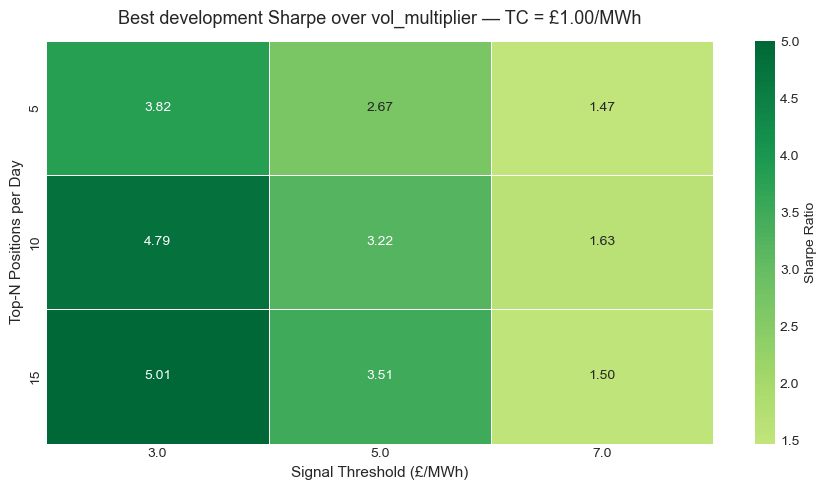

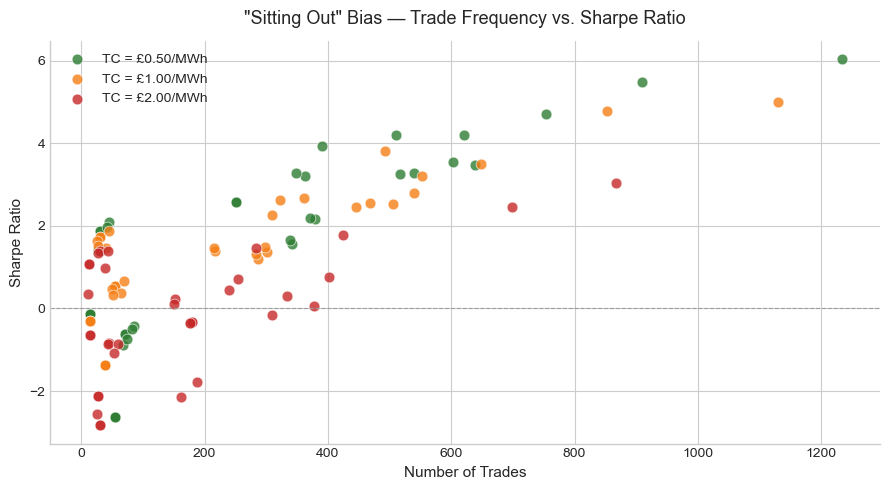

In [10]:
s4_df = pd.DataFrame(s4_results)

# --- Heatmap: Sharpe by top_n × threshold (TC = £1.00 reference slice for exploration) ---
#
# The grid now has a fourth axis, vol_multiplier, so (top_n, threshold) is no
# longer unique and a plain pivot has duplicate index entries. Each cell shows
# the best development Sharpe available at that pair over the vol_multiplier
# values swept — an exploration view of where the parameter space is good, not
# the decision, which happens below on the full grid.
pivot_slice = s4_df[s4_df["transaction_cost"] == 1.00]
pivot = pivot_slice.pivot_table(
    index="top_n", columns="threshold", values="sharpe", aggfunc="max"
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Sharpe Ratio"},
)
ax.set_title("Best development Sharpe over vol_multiplier — TC = £1.00/MWh",
             fontsize=13, pad=12)
ax.set_xlabel("Signal Threshold (£/MWh)", fontsize=11)
ax.set_ylabel("Top-N Positions per Day", fontsize=11)
plt.tight_layout()
plt.show()

# --- Scatter: n_trades vs Sharpe — primary decision metric ---
fig, ax = plt.subplots(figsize=(9, 5))

tc_colors = {0.50: "#2E7D32", 1.00: "#F57F17", 2.00: "#C62828"}
tc_labels = {0.50: "TC = £0.50/MWh", 1.00: "TC = £1.00/MWh", 2.00: "TC = £2.00/MWh"}

for tc, color in tc_colors.items():
    subset = s4_df[s4_df["transaction_cost"] == tc]
    ax.scatter(
        subset["n_trades"], subset["sharpe"],
        c=color, label=tc_labels[tc], s=60, alpha=0.8, edgecolors="white", linewidths=0.5,
    )

ax.axhline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.set_title('"Sitting Out" Bias — Trade Frequency vs. Sharpe Ratio',
             fontsize=13, pad=12)
ax.set_xlabel("Number of Trades", fontsize=11)
ax.set_ylabel("Sharpe Ratio", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# --- Best-run selection: development Sharpe, tie-broken on return-to-drawdown ---
#
# One rule, matching the prose above exactly. Sharpe is on daily percentage
# returns; Calmar is reported but not selected on, because annualising a 90-day
# return is unstable. Every grid endpoint is eligible.
#
# The liquidity floor is per market day so it keeps its meaning when the
# development window changes length. Prose and code must agree: they disagreed
# before (500 against 1,000) and picked different winners.
MIN_TRADES_PER_DAY = 1.0
RANK = ["sharpe", "return_to_dd"]
active_strategies = s4_df[s4_df["trades_per_day"] >= MIN_TRADES_PER_DAY]

# Per-tier best: proves edge is consistent across execution cost scenarios
best_runs_by_tc = (
    active_strategies
    .sort_values(RANK, ascending=False)
    .groupby("transaction_cost")
    .first()
    .reset_index()
)

print(f"\n=== Best per execution-cost tier (≥ {MIN_TRADES_PER_DAY:.1f} trades/day, development) ===")
print("Ranked: development Sharpe → return-to-drawdown\n")
for _, row in best_runs_by_tc.iterrows():
    print(
        f"  Friction: £{row['transaction_cost']:.2f}/MWh | "
        f"Config: top_n={int(row['top_n'])}, thresh={row['threshold']:.0f}, "
        f"vol_mult={row['vol_multiplier']:.2f} | "
        f"Sharpe: {row['sharpe']:.3f} | R/DD: {row['return_to_dd']:.2f} | "
        f"Trades: {int(row['n_trades'])} ({row['trades_per_day']:.2f}/day)"
    )

# Best at TC = £1.00/MWh — realistic live execution friction
tc1_sorted = (
    active_strategies[active_strategies["transaction_cost"] == 1.00]
    .sort_values(RANK, ascending=False)
)
best_s4 = tc1_sorted.iloc[0]

print(f"\nLiquidity filter: {len(active_strategies)}/{len(s4_df)} configs at "
      f"≥ {MIN_TRADES_PER_DAY:.1f} trades/day")
print("Winning config (TC = £1.00/MWh), on development:")
print(f"  top_n={int(best_s4['top_n'])}, threshold={best_s4['threshold']:.0f}, "
      f"vol_multiplier={best_s4['vol_multiplier']:.2f}, "
      f"tc=£{best_s4['transaction_cost']:.2f}/MWh")
print(f"  Sharpe: {best_s4['sharpe']:.3f} | R/DD: {best_s4['return_to_dd']:.2f} | "
      f"PF: {best_s4['profit_factor']:.2f} | Return: {best_s4['total_return']:+.1%} | "
      f"Win Rate: {best_s4['win_rate']:.1%}")
# Calmar is deliberately not in the headline. Annualising a 90-day return makes
# it enormous and unstable (this run prints in the hundreds), which is exactly
# why selection uses Sharpe on daily percentage returns instead. It is kept in
# the frame for anyone who wants it, with the caveat attached.
print(f"  [Calmar {best_s4['calmar']:.0f} — annualised over a {int(best_s4['development_days'])}-day "
      f"development window, so read it as unstable, not as a ranking]")

---
## Section 5 — Selected-Run Tear Sheet & Capital Context

We deploy the optimal execution configuration to generate a portfolio-quality tear sheet.

**Capital Context:** Returns are reported on a notional capital base with dynamic position sizing (`(current_capital × 2%) / DA_price`). This allows for natural compounding and protects capital by shrinking exposure during the highlighted **Max Drawdown** phases.

Maximum drawdown is reported against both the running equity peak and starting capital.
Position sizing is 2% of running equity per trade; the engine enforces a capital floor at
−20% of starting capital.

The terminal exit is imbalance settlement. This is feasible at the clip sizes modelled
here (10–30 MWh) but does not scale: imbalance is a settlement mechanism without
order-book depth, and sustained directional reliance on it at size would attract
regulatory scrutiny. These results benchmark signal quality; they are not a
capacity-bearing strategy.

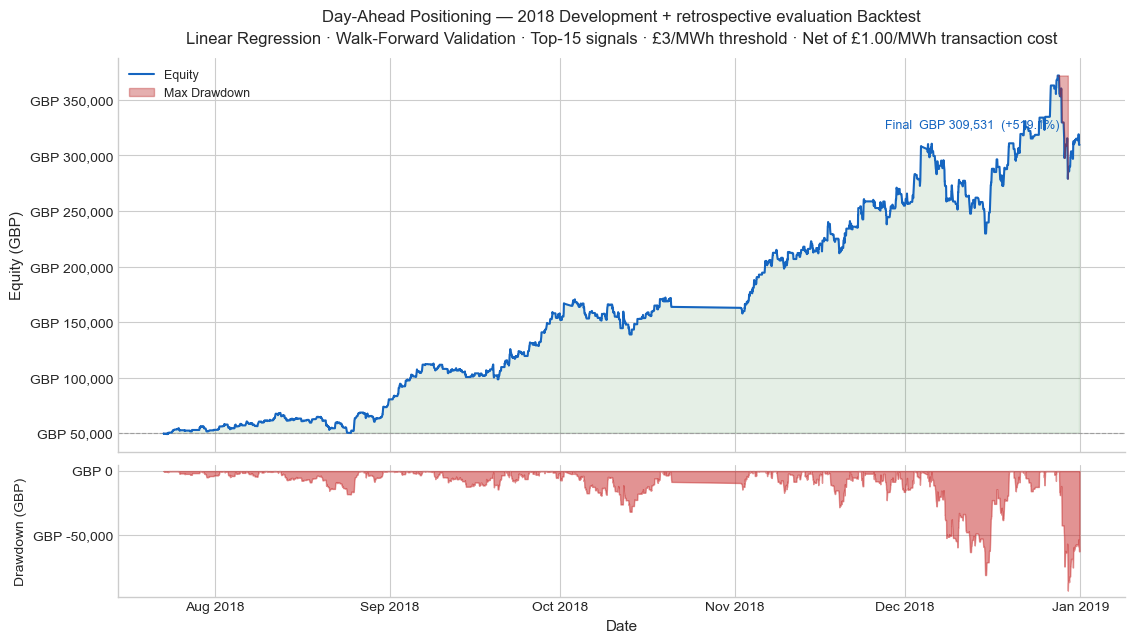


  RESEARCH SUMMARY — s4_n15_t30_vm00_tc10
  Calmar Ratio          226.65
  Sharpe Ratio           4.795
  Total Return         +519.1%
  Profit Factor           1.25
  Win Rate               53.7%
  Max Drawdown      GBP  -92,960
  Active Trades          1,954
  Final Capital     GBP  309,531
  Gross PnL         GBP  387,343
  Traded volume          127,812 MWh
  Total Cost Drag   GBP  127,812
  Net PnL           GBP  259,531
  Time in Market         31.9%
Max drawdown: GBP -92,960  (-25.0% of prior equity peak; -185.9% of starting capital)
Sizing: 2% of running equity per trade; engine capital floor at -20% of start.


In [11]:
best_run = best_s4["run_name"]
# Freeze all choices before evaluating the reserved tail.
_selected_path = REPO_ROOT / f"artifacts/sweeps/{best_run}.yaml"
_frozen = yaml.safe_load(_selected_path.read_text())
_frozen["validation"]["evaluate_holdout"] = True
_selected_path.write_text(yaml.safe_dump(_frozen))
run_experiment(str(_selected_path), best_run)
m = load_metrics(best_run)
tp = m["trading_performance"]

pnl_df = pd.read_csv(
    REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/pnl.csv",
    parse_dates=["time"],
)

starting_capital = tp["starting_capital"]
equity      = starting_capital + pnl_df["pnl"].cumsum()
running_max = equity.cummax()
drawdown    = equity - running_max

dd_end_idx   = int(drawdown.idxmin())
dd_start_idx = int(equity.iloc[: dd_end_idx + 1].idxmax())

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

ax1.plot(pnl_df["time"], equity, linewidth=1.5, color="#1565C0", zorder=3, label="Equity")
ax1.axhline(starting_capital, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax1.fill_between(pnl_df["time"], starting_capital, equity,
                 where=(equity >= starting_capital), alpha=0.12, color="#2E7D32", zorder=1)
ax1.fill_between(pnl_df["time"], starting_capital, equity,
                 where=(equity < starting_capital), alpha=0.15, color="#C62828", zorder=1)

ax1.fill_between(
    pnl_df["time"].iloc[dd_start_idx : dd_end_idx + 1],
    running_max.iloc[dd_start_idx : dd_end_idx + 1],
    equity.iloc[dd_start_idx : dd_end_idx + 1],
    alpha=0.35, color="#B71C1C", label="Max Drawdown", zorder=4,
)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}"))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_ylabel("Equity (GBP)", fontsize=11)

title = (
    f"Day-Ahead Positioning — 2018 Development + retrospective evaluation Backtest\n"
    f"{_frozen['model']['type'].replace('_', ' ').title()} · Walk-Forward Validation · "
    f"Top-{int(best_s4['top_n'])} signals · "
    f"£{best_s4['threshold']:.0f}/MWh threshold · "
    f"Net of £{best_s4['transaction_cost']:.2f}/MWh transaction cost"
)
ax1.set_title(title, fontsize=12, pad=10, linespacing=1.6)

ax1.legend(loc="upper left", fontsize=9)
ax1.annotate(
    f"Final  GBP {equity.iloc[-1]:,.0f}  ({tp['total_return_pct']:+.1%})",
    xy=(pnl_df["time"].iloc[-1], equity.iloc[-1]),
    xytext=(-140, 12), textcoords="offset points",
    fontsize=9, color="#1565C0",
)
ax1.spines[["top", "right"]].set_visible(False)

ax2.fill_between(pnl_df["time"], drawdown, 0, alpha=0.5, color="#C62828")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}"))
ax2.set_ylabel("Drawdown (GBP)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# --- PnL Decomposition ---
net_pnl = tp["final_capital"] - tp["starting_capital"]

# Costs come from the engine's fill ledger, which records the MWh actually
# traded. Multiplying a trade *count* by a £/MWh fee is not a cost and was out
# by a factor of ~28 on the previous winning run: it reported £1,069 of drag
# against £29,760.67 genuinely paid. The engine always deducted the right
# figure from net PnL; it was the gross/cost decomposition that was wrong.
total_transaction_costs = tp["total_transaction_costs"]
total_mwh = tp["total_position_mwh"]
gross_pnl = tp["gross_pnl"]

total_periods = len(pnl_df)
active_periods = (pnl_df["pnl"] != 0).sum()
pct_time_in_market = active_periods / total_periods

calmar_ratio = tp.get(
    "calmar_ratio",
    tp["total_return_pct"] / (abs(tp["max_drawdown"]) / tp["starting_capital"])
    if tp["max_drawdown"] != 0 else float("nan"),
)

sep = "=" * 50
print(f"\n{sep}")
print(f"  RESEARCH SUMMARY — {best_run}")
print(sep)
print(f"  Calmar Ratio      {calmar_ratio:>10.2f}")
print(f"  Sharpe Ratio      {tp['sharpe_ratio']:>10.3f}")
print(f"  Total Return      {tp['total_return_pct']:>+10.1%}")
print(f"  Profit Factor     {tp['profit_factor']:>10.2f}")
print(f"  Win Rate          {tp['win_rate']:>10.1%}")
print(f"  Max Drawdown      GBP {tp['max_drawdown']:>8,.0f}")
print(f"  Active Trades     {tp['n_trades']:>10,}")
print(f"  Final Capital     GBP {tp['final_capital']:>8,.0f}")
print(sep)
print(f"  Gross PnL         GBP {gross_pnl:>8,.0f}")
print(f"  Traded volume     {total_mwh:>12,.0f} MWh")
print(f"  Total Cost Drag   GBP {total_transaction_costs:>8,.0f}")
print(f"  Net PnL           GBP {net_pnl:>8,.0f}")
print(f"  Time in Market    {pct_time_in_market:>10.1%}")
print(sep)

# Drawdown relative to the running equity peak and to starting capital.
_dd_pct_of_peak  = (drawdown.min() / running_max.iloc[dd_end_idx])
_dd_pct_of_start = (drawdown.min() / starting_capital)
print(f"Max drawdown: GBP {drawdown.min():,.0f}  "
      f"({_dd_pct_of_peak:.1%} of prior equity peak; "
      f"{_dd_pct_of_start:.1%} of starting capital)")
print("Sizing: 2% of running equity per trade; engine capital floor at -20% of start.")

---
## Section 6 — Naive-baseline decomposition

Part of any imbalance-settled PnL is compensation for bearing settlement risk rather
than forecast skill. To size that component, the identical signal machinery — gating,
top-N schedule, costs, execution settings — is run with the ML prediction replaced by
the 7-day seasonal naive spread from Section 1. The difference between the two PnLs is
the component attributable to the model.

In [12]:
# ── Same pipeline, naive forecast: 7-day-ago spread as the prediction ────────
import sys as _sys
_root = str(REPO_ROOT)
if _root not in _sys.path:
    _sys.path.insert(0, _root)
from src.models.signal import (
    compute_execution_buffer, compute_volatility_threshold, generate_signal_from_dataframe,
)
from src.backtest.engine import run_backtest

_sig_df = proc[["time", "day_ahead_price", "system_sell_price",
                "system_buy_price", "mid_price", "actual_spread"]].copy()
_sig_df["predicted_spread"] = _sig_df["actual_spread"].shift(336)  # 7-day naive
# The hurdle is the known round trip, and the volatility term is the dispersion
# of the cash-out-to-auction gap. Both used to be built from (SBP - SSP), which
# is zero in every settlement period under single cash-out pricing.
_exec_buffer = compute_execution_buffer(
    transaction_cost=float(best_s4["transaction_cost"]), slippage=0.0)
_sig_df["vol_threshold"]   = compute_volatility_threshold(
    _sig_df["system_buy_price"], _sig_df["day_ahead_price"])
_sig_df = _sig_df.dropna(subset=["predicted_spread"])

# Same gates as the winning run, read from it rather than restated.
# (The wrapper returns the frame with a `signal` column attached.)
_sig_df = generate_signal_from_dataframe(
    _sig_df, threshold=float(best_s4["threshold"]), top_n=int(best_s4["top_n"]),
    execution_buffer=_exec_buffer, vol_multiplier=float(best_s4["vol_multiplier"]),
)

# Same OOS window as the stored best run (bounds normalised to UTC).
_w0 = pd.to_datetime(pnl_df["time"].min(), utc=True)
_w1 = pd.to_datetime(pnl_df["time"].max(), utc=True)
_oos = _sig_df[_sig_df["time"].isin(pd.to_datetime(pnl_df["time"], utc=True))].reset_index(drop=True)

_naive_pnl, _naive_m = run_backtest(
    _oos["signal"].to_numpy(),
    _oos["day_ahead_price"].to_numpy(),
    _oos["system_sell_price"].to_numpy(),
    _oos["system_buy_price"].to_numpy(),
    starting_capital=starting_capital,
    timestamps=_oos["time"].values,
    cost_per_trade=float(best_s4["transaction_cost"]),
    mid_prices=_oos["mid_price"].to_numpy(),
    predicted_spreads=_oos["predicted_spread"].to_numpy(),
    baseline_hedge_ratio=0.0,          # identical execution to the tournament runs
    take_profit_pct=999.0,
    stop_loss_price_delta=999.0,
)

_ml_pnl    = tp["total_pnl"]
_beta_pnl  = _naive_m["total_pnl"]
_alpha_pnl = _ml_pnl - _beta_pnl
print("=== Naive-rule counterfactual comparison (same window, gates, costs) ===")
print(f"  ML strategy net PnL     : GBP {_ml_pnl:>10,.0f}   (Sharpe {tp['sharpe_ratio']:.2f})")
print(f"  Naive-rule net PnL      : GBP {_beta_pnl:>10,.0f}   "
      f"(Sharpe {_naive_m['sharpe_ratio']:.2f}, {_naive_m['n_trades']} trades, "
      f"halted={_naive_m['halted_at_period'] is not None})")
print(f"  PnL difference      : GBP {_alpha_pnl:>10,.0f}")

=== Naive-rule counterfactual comparison (same window, gates, costs) ===
  ML strategy net PnL     : GBP    259,531   (Sharpe 4.80)
  Naive-rule net PnL      : GBP    -15,324   (Sharpe -2.12, 518 trades, halted=True)
  PnL difference      : GBP    274,855


## Section 7 — Retrospective evaluation

The frozen model and signal settings are evaluated on the final 60 market days, excluded from the current development search. This tail has been examined in prior research, so it is not a new untouched sample. The development and evaluation accounts each start at £50,000. Conditional bootstrap intervals resample observed daily outcomes; they do not rerun sizing, halts or selection.


In [13]:
# ── Score the frozen configuration once on the reserved retrospective evaluation split ─────────────
_hold = load_metrics(best_run)["trading_performance_by_split"].get("holdout")
if _hold is None:
    print("No holdout in this run — set validation.holdout_days and re-run.")
else:
    _pnl_all = pd.read_csv(
        REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/pnl.csv",
        parse_dates=["time"],
    )
    _preds = pd.read_csv(
        REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/predictions.csv",
        parse_dates=["time"],
    )
    _dev = development_metrics(best_run)

    print("=" * 66)
    print("  EVALUATION — 60 market days excluded from current selection")
    print("=" * 66)
    rows = [
        ("Executed trades", f"{_dev['n_trades']:,}", f"{_hold['n_trades']:,}"),
        ("Net PnL", f"GBP {_dev['total_pnl']:,.0f}", f"GBP {_hold['total_pnl']:,.0f}"),
        ("Sharpe (daily % returns)", f"{_dev['sharpe_ratio']:.2f}", f"{_hold['sharpe_ratio']:.2f}"),
        ("Max drawdown", f"GBP {_dev['max_drawdown']:,.0f}", f"GBP {_hold['max_drawdown']:,.0f}"),
        ("Traded volume (MWh)", f"{_dev['total_position_mwh']:,.0f}",
         f"{_hold['total_position_mwh']:,.0f}"),
        ("Transaction costs", f"GBP {_dev['total_transaction_costs']:,.0f}",
         f"GBP {_hold['total_transaction_costs']:,.0f}"),
        ("Win rate", f"{_dev['win_rate']:.1%}", f"{_hold['win_rate']:.1%}"),
    ]
    print(f"  {'':<26}{'development':>18}{'HOLDOUT':>18}")
    for label, d, h in rows:
        print(f"  {label:<26}{d:>18}{h:>18}")
    print("=" * 66)
    print("  Development is in-sample to the search that produced it.")
    print("  The evaluation tail is excluded from this selection but has been inspected in prior research.")

from src.evaluation.holdout_report import score_holdout
_prediction = pd.read_csv(REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/predictions.csv")
_signal = pd.read_csv(REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/signals.csv")
_prediction["time"] = pd.to_datetime(_prediction["time"], utc=True)
_signal["time"] = pd.to_datetime(_signal["delivery_time"], utc=True)
_prices = pd.read_parquet(REPO_ROOT / f"artifacts/da_positioning/{best_run}/features/features.parquet")
_prices["time"] = pd.to_datetime(_prices["time"], utc=True)
_prediction = _prediction.merge(_prices[["time", "day_ahead_price", "system_sell_price", "system_buy_price", "mid_price"]], on="time", validate="one_to_one")
_evaluation = _prediction.merge(_signal[["time", "signal"]], on="time", validate="one_to_one")
_report = score_holdout(_evaluation[_evaluation["split"] == "holdout"],
                       cost_per_trade=float(best_s4["transaction_cost"]),
                       baseline_hedge_ratio=0, take_profit_pct=999, stop_loss_price_delta=999)
_report_path = REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/holdout_report.json"
_report_path.write_text(json.dumps(_report, indent=2))
print(json.dumps(_report, indent=2))


  EVALUATION — 60 market days excluded from current selection
                                   development           HOLDOUT
  Executed trades                        1,130               824
  Net PnL                          GBP 113,700        GBP 44,542
  Sharpe (daily % returns)                5.01              4.42
  Max drawdown                     GBP -31,605       GBP -28,393
  Traded volume (MWh)                   43,633            25,711
  Transaction costs                 GBP 43,633        GBP 25,711
  Win rate                               57.2%             49.0%
  Development is in-sample to the search that produced it.
  The evaluation tail is excluded from this selection but has been inspected in prior research.
{
  "days": 60,
  "n_trades": 824,
  "total_pnl": 44542.477531986544,
  "gross_pnl": 70253.84834154014,
  "total_transaction_costs": 25711.370809553595,
  "total_position_mwh": 25711.370809553595,
  "sharpe_ratio": 4.419670119042743,
  "max_drawdown": -28393.3143

In [14]:
# Write the winning run name so notebooks 02 and 03 pick it up automatically
import json as _json

# Root-relative, via the marker file. Writing to Path("..") landed the manifest
# under research/artifacts when the notebook ran from its own directory, and one
# level *above* the repo when it ran from the root - while notebooks 02 and 03
# read REPO_ROOT/artifacts. A stale file at the read path then silently pinned a
# different run than the one just selected.
_best_run_path = REPO_ROOT / "artifacts" / "da_positioning" / "best_run.json"
_best_run_path.parent.mkdir(parents=True, exist_ok=True)
_best_run_path.write_text(_json.dumps({"best_run": best_run}, indent=2))
print(f"  Run name: {best_run}")
# Publish a portable canonical config with the frozen selection and the BESS settings.
_example = REPO_ROOT / "configs/config.example.yaml"
_bess = yaml.safe_load(_example.read_text())["bess"]
_canonical = dict(_frozen)
_canonical.pop("training_cache_dir", None)
_canonical["bess"] = _bess
_example.write_text("# Generated by notebook 01 from development-only selection.\n"
                    "# The 2018 tail is a retrospective evaluation split; data end is exclusive.\n"
                    + yaml.safe_dump(_canonical, sort_keys=False))


  Run name: s4_n15_t30_vm00_tc10
Out[14]: 1202


1202